Isabella Esquivel
Feburary 26, 2026
University of Miami
College of Engineering
Coral Gables, FL 33146


# 1. Introduction


#### Background

According to Mayo Clinic, heart failure occurs when the heart muscle does not pump blood as it should, causing blood to back up. This may lead to fluid building in the lungs, causing shortness of breath. The Heart Failure Society of America reported that heart failure was a contributing cause in 425,147 deaths in the United States in 2022, making up 45% of cardiovascular deaths.

Medical records of patients who have undergone heart failure could be used to analyze and identify patterns in patient survival. These clinical factors include ejection fraction, serum creatinine, and serum sodium as well as other demographic factors, such as age and gender. Understanding how these clinical indicators could **predict the event of death** following heart failure is essential to improve disease management.

#### Prior Studies

Chicco and Jurman(2020) previously demonstrated that the strongest predictors of mortality among heart failure patients were serum creatinine and ejection fraction by using machine learning classification techniques. Additionally, in 2017, Ahmad and colleagues conducted a survival analysis, and found that age, renal dysfunction(having serum creatinine greater than
its normal level 1.5), high blood pressure, high levels of anaemia, and lower values of ejection fraction as the most significant risk factors for death following heart failure.

#### Study Objective

Therefore, the present study aims to apply Logistic Regression, Linear Discriminant Analysis(LDA), Quadratic Discriminant Analysis (QDA) and Naive Bayes classification techniques to investigate how demographic and clinical variables could be used to predict death in heart failure patients.

# 2. Data and Methods

 ### Dataset Description

The dataset used consists of 299 patients with heart failure. 13 clinical and demographic variables were collected from each patient, including age, sex, anaemia status, diabetes status, high blood pressure, smoking status, serum creatinine, serum sodium, creatinine phosphoinase(CPK), platelet count, follow-up time, ejection fraction, and death event (see table 1 for descriptions).

Table 1

In [64]:
knitr::kable(variable_table, caption = "Table 1. Description of Clinical Variables Included in the Heart Failure Dataset")




Table: Table 1. Description of Clinical Variables Included in the Heart Failure Dataset

|Variable                 |Description                                           |
|:------------------------|:-----------------------------------------------------|
|age                      |Age of the patient (years)                            |
|anaemia                  |Decrease of red blood cells or hemoglobin (boolean)   |
|creatinine_phosphokinase |Level of CPK enzyme in blood (mcg/L)                  |
|diabetes                 |Presence of diabetes (boolean)                        |
|ejection_fraction        |Percentage of blood leaving heart at each contraction |
|high_blood_pressure      |Presence of hypertension (boolean)                    |
|platelets                |Platelets in blood (kiloplatelets/mL)                 |
|sex                      |Sex (binary: 0 = female, 1 = male)                    |
|serum_creatinine         |Serum creatinine level (mg/dL)                      

In [65]:
HeartFailure <- read.csv("HeartFailure.csv")

In [66]:
head(HeartFailure)
names(HeartFailure)

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
,<dbl>,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>
1,75,0,582,0,20,1,265000,1.9,130,1,0,4,1
2,55,0,7861,0,38,0,263358,1.1,136,1,0,6,1
3,65,0,146,0,20,0,162000,1.3,129,1,1,7,1
4,50,1,111,0,20,0,210000,1.9,137,1,0,7,1
5,65,1,160,1,20,0,327000,2.7,116,0,0,8,1
6,90,1,47,0,40,1,204000,2.1,132,1,1,8,1


[1] "age"                      "anaemia"                 
 [3] "creatinine_phosphokinase" "diabetes"                
 [5] "ejection_fraction"        "high_blood_pressure"     
 [7] "platelets"                "serum_creatinine"        
 [9] "serum_sodium"             "sex"                     
[11] "smoking"                  "time"                    
[13] "DEATH_EVENT"

In [67]:
?HeartFailure

Summary of each clinical and demographic factor in the Heart Failure Dataset:

In [68]:
summary(HeartFailure)

      age           anaemia       creatinine_phosphokinase    diabetes     
 Min.   :40.00   Min.   :0.0000   Min.   :  23.0           Min.   :0.0000  
 1st Qu.:51.00   1st Qu.:0.0000   1st Qu.: 116.5           1st Qu.:0.0000  
 Median :60.00   Median :0.0000   Median : 250.0           Median :0.0000  
 Mean   :60.83   Mean   :0.4314   Mean   : 581.8           Mean   :0.4181  
 3rd Qu.:70.00   3rd Qu.:1.0000   3rd Qu.: 582.0           3rd Qu.:1.0000  
 Max.   :95.00   Max.   :1.0000   Max.   :7861.0           Max.   :1.0000  
 ejection_fraction high_blood_pressure   platelets      serum_creatinine
 Min.   :14.00     Min.   :0.0000      Min.   : 25100   Min.   :0.500   
 1st Qu.:30.00     1st Qu.:0.0000      1st Qu.:212500   1st Qu.:0.900   
 Median :38.00     Median :0.0000      Median :262000   Median :1.100   
 Mean   :38.08     Mean   :0.3512      Mean   :263358   Mean   :1.394   
 3rd Qu.:45.00     3rd Qu.:1.0000      3rd Qu.:303500   3rd Qu.:1.400   
 Max.   :80.00     Max.   :1.0

The pairwise scatterplots allow visual assessment of potential relationships between predictors and mortality status.

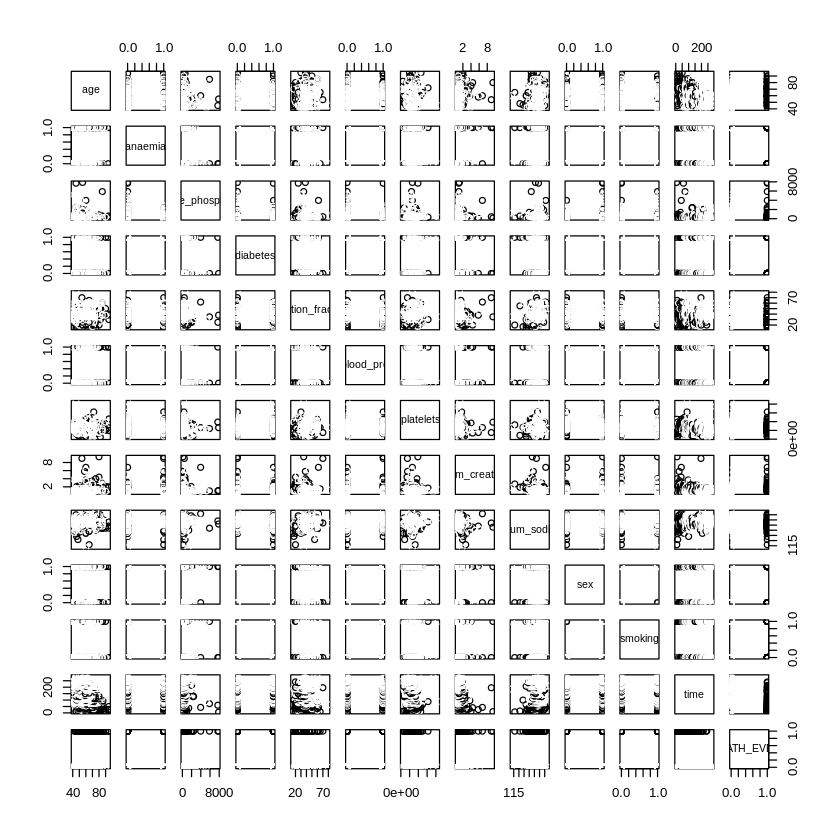

In [7]:
pairs(HeartFailure,col=HeartFailure$DEATH_EVENT)

# Model

### Logistic Regression

Next, we fit a logistic regression model to predict the probability of death using the available clinical and demographic predictors.


In [91]:
glm.fits <- glm(
    DEATH_EVENT ~ .-time,
    data = HeartFailure, family = binomial
  )

Age, creatinine phosphokinase, ejection fraction, and serum creatinine were statistically significant predictors at the 0.05 level. In particular, lower ejection fraction and higher serum creatinine were strongly associated with increased mortality risk.

In [92]:
summary(glm.fits)


Call:
glm(formula = DEATH_EVENT ~ . - time, family = binomial, data = HeartFailure)

Coefficients:
                           Estimate Std. Error z value Pr(>|z|)    
(Intercept)               4.964e+00  4.601e+00   1.079 0.280625    
age                       5.569e-02  1.313e-02   4.241 2.23e-05 ***
anaemia                   4.179e-01  3.009e-01   1.389 0.164904    
creatinine_phosphokinase  2.905e-04  1.428e-04   2.034 0.041907 *  
diabetes                  1.514e-01  2.974e-01   0.509 0.610644    
ejection_fraction        -7.032e-02  1.486e-02  -4.731 2.23e-06 ***
high_blood_pressure       4.189e-01  3.061e-01   1.369 0.171092    
platelets                -7.094e-07  1.617e-06  -0.439 0.660857    
serum_creatinine          6.619e-01  1.734e-01   3.817 0.000135 ***
serum_sodium             -5.667e-02  3.338e-02  -1.698 0.089558 .  
sex                      -3.990e-01  3.508e-01  -1.137 0.255394    
smoking                   1.356e-01  3.486e-01   0.389 0.697300    
---
Signif. code

The smallest p-value corresponds to ejection_fraction, indicating a strong negative association with mortality.

The `coef()` function was used in order to access just the coefficients for this fitted model.

In [93]:
coef(glm.fits)

(Intercept)                      age                  anaemia 
            4.964299e+00             5.569092e-02             4.179298e-01 
creatinine_phosphokinase                 diabetes        ejection_fraction 
            2.905410e-04             1.514076e-01            -7.032203e-02 
     high_blood_pressure                platelets         serum_creatinine 
            4.189377e-01            -7.093639e-07             6.618606e-01 
            serum_sodium                      sex                  smoking 
           -5.666672e-02            -3.990140e-01             1.355892e-01

The `summary()` function was also used to assess particular aspects of the fitted model, such as the $p$-values for the coefficients.

In [94]:
summary(glm.fits)$coef

,Estimate,Std. Error,z value,Pr(>|z|)
(Intercept),4.964299e+00,4.601187e+00,1.0789169,2.806248e-01
age,5.569092e-02,1.313307e-02,4.2405091,2.230134e-05
anaemia,4.179298e-01,3.009358e-01,1.3887673,1.649035e-01
creatinine_phosphokinase,2.905410e-04,1.428113e-04,2.0344399,4.190726e-02
diabetes,1.514076e-01,2.973705e-01,0.5091549,6.106437e-01
ejection_fraction,-7.032203e-02,1.486333e-02,-4.7312425,2.231497e-06
high_blood_pressure,4.189377e-01,3.060838e-01,1.3687025,1.710923e-01
platelets,-7.093639e-07,1.616858e-06,-0.4387299,6.608573e-01
serum_creatinine,6.618606e-01,1.734150e-01,3.8166280,1.352879e-04
serum_sodium,-5.666672e-02,3.337789e-02,-1.6977324,8.955827e-02


In [95]:
summary(glm.fits)$coef[, 4]

(Intercept)                      age                  anaemia 
            2.806248e-01             2.230134e-05             1.649035e-01 
creatinine_phosphokinase                 diabetes        ejection_fraction 
            4.190726e-02             6.106437e-01             2.231497e-06 
     high_blood_pressure                platelets         serum_creatinine 
            1.710923e-01             6.608573e-01             1.352879e-04 
            serum_sodium                      sex                  smoking 
            8.955827e-02             2.553945e-01             6.972997e-01

The `predict()` function is used to estimate the probability of death for each patient based on the fitted logistic regression model. By specifying `type = "response"`, R returns predicted probabilities of the form `P(Y = 1 | X)`, where 1 represents death and 0 represents survival.The printed values therefore represent the estimated probability that each patient experienced a death event. Because the response variable `DEATH_EVENT` is already coded as 0 (survival) and 1 (death), the predicted probabilities directly correspond to the likelihood of death for each patient.

In [96]:
glm.probs <- predict(glm.fits, type = "response")


The First Ten Probabilities:

In [97]:
glm.probs[1:10]

1          2          3          4          5          6          7 
0.83570003 0.51862820 0.59682594 0.43506827 0.94132717 0.81993224 0.75352081 
         8          9         10 
0.07354421 0.04949408 0.99747015

In [98]:
attach(HeartFailure)

The following objects are masked _by_ .GlobalEnv:

    DEATH_EVENT, ejection_fraction, serum_creatinine


The following objects are masked from HeartFailure (pos = 3):

    age, anaemia, creatinine_phosphokinase, DEATH_EVENT, diabetes,
    ejection_fraction, high_blood_pressure, platelets,
    serum_creatinine, serum_sodium, sex, smoking, time


The following objects are masked from HeartFailure (pos = 6):

    age, anaemia, creatinine_phosphokinase, DEATH_EVENT, diabetes,
    ejection_fraction, high_blood_pressure, platelets,
    serum_creatinine, serum_sodium, sex, smoking, time




This is not needed as the data is already in 0(no death) and 1(death).

In [99]:
# contrasts(DEATH_EVENT)

To convert the predicted probabilities into class labels, we classify patients as death (1) if the predicted probability exceeds 0.5 and survival (0) otherwise. The resulting confusion matrix summarizes how well the model performed on the training data. The diagonal values represent correct classifications, while the off-diagonal values represent misclassifications.

In [100]:
glm.pred=ifelse(glm.probs>0.5,"1","0")

From the confusion matrix, the model correctly identified 183 patients who survived and 47 patients who died. However, it incorrectly classified 49 survivors as deaths and 20 deaths as survivals. Overall, the training accuracy was approximately 76.9%, meaning that about three-quarters of patients were correctly classified. The training error was about 23.1%.

In [101]:
table(glm.pred, HeartFailure$DEATH_EVENT)

        
glm.pred   0   1
       0 183  49
       1  20  47

In [102]:
mean(glm.pred == DEATH_EVENT)

[1] 0.7692308

Although this accuracy may appear somewhat strong, it reflects performance on the same data used to fit the model. This training accuracy may therefore be overly optimistic and does not necessarily reflect how well the model would perform on new, unseen patient data. For this reason, a separate test set is used to obtain a more realistic evaluation of predictive performance.

The first 200 observations were used as the training set, and the remaining 99 observations were held out as the test set.

In [103]:
train <- (1:nrow(HeartFailure) <= 200)

This extracts the 99 held-out patients that were not included in the training set to be used as the test dataset.

In [104]:
HeartFailure.200 <-HeartFailure[!train, ]

In [105]:
dim(HeartFailure.200)

[1] 99 13

In [106]:
DEATH_EVENT <- HeartFailure$DEATH_EVENT

In [107]:
DEATH_EVENT.200 <- DEATH_EVENT[!train]

This fits a logistic regression model using only the 200 training patients to predict the probability of death based on the available clinical variables.

In [108]:
glm.test <- glm(
    DEATH_EVENT ~ .-time ,
    data = HeartFailure, family = binomial, subset = train
  )

Next, this generates predicted probabilities of death for each of the 99 patients in the held-out test set.

In [109]:
glm.probstest <- predict(glm.test,HeartFailure.200,
    type = "response")

In [110]:
glm.predtest <- rep(0, length(glm.probstest))

Patients with a predicted probability of death greater than 0.5 are classified as death (1), while the rest remain classified as survival (0).

In [111]:
glm.predtest[glm.probstest > 0.5] <- 1

The confusion matrix shows that the model correctly identified 72 survivors and 6 deaths, while incorrectly classifying 1 survivor as death and 20 deaths as survival.

In [115]:
table(glm.predtest, DEATH_EVENT.200)

            DEATH_EVENT.200
glm.predtest  0  1
           0 72  1
           1 20  6

The test accuracy is approximately 78.8%, meaning that about four out of five patients in the test set were correctly classified. The test error rate is approximately 21.2%.

In [113]:
mean(glm.predtest == DEATH_EVENT.200)

[1] 0.7878788

In [114]:
mean(glm.predtest != DEATH_EVENT.200)

[1] 0.2121212

The earlier logistic regression model included all predictors, but several variables were not statistically significant. To simplify the model and focus on the strongest clinical predictors, we refit the logistic regression using only ejection fraction and serum creatinine, which consistently showed strong associations with mortality. Reducing the number of predictors can sometimes improve performance by decreasing model variance and focusing on the most informative variables.

In [120]:
glm.fits.small <- glm(
    DEATH_EVENT ~ ejection_fraction + serum_creatinine,
    data = HeartFailure,
    family = binomial,
    subset = train
)

glm.probs.small <- predict(glm.fits.small,
                           HeartFailure.200,
                           type = "response")

glm.pred.small <- rep(0, length(glm.probs.small))
glm.pred.small[glm.probs.small > 0.5] <- 1

table(glm.pred.small, DEATH_EVENT.200)

cat("\nTest Accuracy:\n")
mean(glm.pred.small == DEATH_EVENT.200)

cat("\nPrecision (Survival Prediction):\n")
78/(78+14)

cat("\nPrecision (Death Prediction):\n")
7 / (7 + 14)

              DEATH_EVENT.200
glm.pred.small  0  1
             0 78  0
             1 14  7


Test Accuracy:


[1] 0.8585859


Precision (Survival Prediction):


[1] 0.8478261


Precision (Death Prediction):


[1] 0.3333333

Now the results appear to be stronger: approximately 85.9% of the patients in the test set were correctly classified. However, it is important to examine the confusion matrix. While the model performs extremely well when predicting survival, with a precision of 84.78% for patients predicted to survive, its precision for death predictions is substantially lower at 33.33%. This means that although the model correctly identifies most survivors, many of the patients predicted to die do not actually experience the event. The overall accuracy appears high, but the model’s reliability differs considerably depending on which outcome is being predicted.

For a patient with an `ejection fraction` of 25% and `serum creatinine` of 1.8 mg/dL, the model estimates a 69.1% probability of death. In contrast, a 55-year-old patient with an `ejection fraction` of 45% and `serum creatinine` of 1.0 mg/dL has an estimated mortality probability of 27.2%. These results demonstrate how reduced `ejection fraction`, and elevated creatinine substantially increase predicted mortality risk.

In [121]:
predict(glm.fits.small,
        newdata = data.frame(
          age = c(70, 55),
          ejection_fraction = c(25, 45),
          serum_creatinine = c(1.8, 1.0)
        ),
        type = "response")

1         2 
0.6911793 0.2721334

### Linear Discriminant Analysis

We next apply Linear Discriminant Analysis (LDA) to the heart failure dataset. LDA is used to classify patients into survival (0) or death (1) based on ejection fraction and serum creatinine. The model is fitted using only the training data (the first 200 patients), and its performance is later evaluated on the held-out test set.

In [122]:
library(MASS)

Call:
lda(DEATH_EVENT ~ ejection_fraction + serum_creatinine, data = HeartFailure, 
    subset = train)

Prior probabilities of groups:
    0     1 
0.555 0.445 

Group means:
  ejection_fraction serum_creatinine
0          41.42342         1.178829
1          33.62921         1.772809

Coefficients of linear discriminants:
                          LD1
ejection_fraction -0.06256253
serum_creatinine   0.68962763

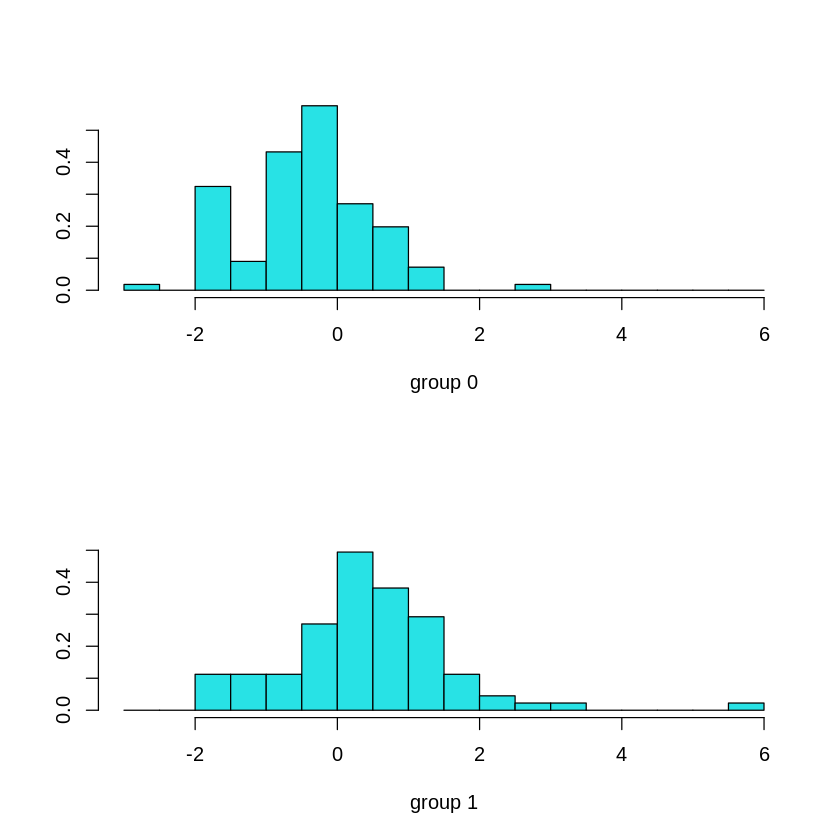

In [123]:
lda.fit <- lda(
  DEATH_EVENT ~ ejection_fraction + serum_creatinine,
  data = HeartFailure,
  subset = train
)

lda.fit
plot(lda.fit)

The LDA output indicates that $55.5$% of the training observations correspond to patients who survived, while $44.5$% correspond to patients who died. It also provides the group means; these are the average values of each predictor within each class and are used by LDA as estimates of $\mu_k$. The group means suggest that patients who died tend to have lower ejection fractions (33.63 vs 41.42) and higher serum creatinine levels (1.77 vs 1.18) compared to patients who survived.

The coefficients of linear discriminants output provides the linear combination of ejection_fraction and serum_creatinine. Specifically, the discriminant score is computed as


`-0.0625 X ejection_fraction + 0.6896 x serum_creatinine`



If this linear combination is large, the LDA classifier will tend to predict death, and if it is small, it will tend to predict survival. The negative coefficient on ejection fraction and the positive coefficient on serum creatinine align with clinical expectations: lower cardiac function and elevated creatinine increase mortality risk.

The plot() function produces plots of the linear discriminants, for each of the training observations. The survival (0) and death (1) groups are displayed separately.

The `predict() `function applied to the LDA model returns three components. The first component, `class`, contains the predicted classification for each patient in the test set (0 = survival, 1 = death). The second component, `posterior`, provides the estimated probability that each patient belongs to either the survival or death group. The third component, `x`, contains the computed linear discriminant scores used to separate the two groups.

In [35]:
lda.pred <- predict(lda.fit, HeartFailure.200)
names(lda.pred)

[1] "class"     "posterior" "x"

The LDA classifier achieved a test accuracy of 84.85%, which is very similar to the logistic regression model of 85.86%. The LDA model correctly identified all 7 deaths in the test set, resulting in 100% sensitivity, while maintaining strong overall performance. These results indicate that LDA and logistic regression produce nearly identical classification outcomes in this setting.

In [36]:
lda.class <- lda.pred$class
table(lda.class, DEATH_EVENT.200)
mean(lda.class == DEATH_EVENT.200)

         DEATH_EVENT.200
lda.class  0  1
        0 77  0
        1 15  7

[1] 0.8484848

Applying a $50$\,\% threshold to the posterior probabilities allows us to recreate the predictions contained in `lda.pred$class`.

How many patients were classified into each group?

In [124]:
sum(lda.pred$posterior[, 1] >= .5)
sum(lda.pred$posterior[, 1] < .5)

[1] 77

[1] 22

The posterior probabilities represent the model’s estimated likelihood of survival for each patient, and the class labels are obtained by classifying patients based on whether this probability exceeds 0.5.

In [38]:
lda.pred$posterior[1:20, 1]
lda.class[1:20]

201        202        203        204        205        206        207 
0.75407701 0.85530863 0.86279918 0.14997947 0.69842408 0.71805727 0.68523334 
       208        209        210        211        212        213        214 
0.64652118 0.65795046 0.62181437 0.34594444 0.88214296 0.72472251 0.43083874 
       215        216        217        218        219        220 
0.62181437 0.54683035 0.78200578 0.06837338 0.57728205 0.63625199

[1] 0 0 0 1 0 0 0 0 0 0 1 0 0 1 0 0 0 1 0 0
Levels: 0 1

Posterior probability threshold other than 50%

No patients in the test set had a posterior probability of survival greater than 90%, indicating that the model was not extremely confident in predicting survival for any individual patient.

In [39]:
sum(lda.pred$posterior[, 1] > .9)

[1] 0

In [40]:
max(lda.pred$posterior[, 1])

[1] 0.882143

Two patients in the test set had a posterior probability of death exceeding 90%, indicating that the model was highly confident in classifying these individuals as high mortality risk.

In [41]:
sum(lda.pred$posterior[, 2] > .9)

[1] 2

In [42]:
max(lda.pred$posterior[, 2])

[1] 0.9348026



### Quadratic Discriminant Analysis

We now fit a Quadratic Discriminant Analysis (QDA) model to the heart failure dataset using ejection fraction and serum creatinine as predictors. The model is trained on the first 200 patients and later evaluated on the held-out test set.

In [43]:
library(MASS)

qda.fit <- qda(
  DEATH_EVENT ~ ejection_fraction + serum_creatinine,
  data = HeartFailure,
  subset = train
)

qda.fit

Call:
qda(DEATH_EVENT ~ ejection_fraction + serum_creatinine, data = HeartFailure, 
    subset = train)

Prior probabilities of groups:
    0     1 
0.555 0.445 

Group means:
  ejection_fraction serum_creatinine
0          41.42342         1.178829
1          33.62921         1.772809

The output displays the prior probabilities and group means for each class. Similar to LDA, patients who died have lower average ejection fraction and higher average serum creatinine compared to survivors.

 But it does not contain the coefficients of the linear discriminants, because the QDA classifier involves  a quadratic, rather than a linear, function of the predictors.

The confusion matrix shows that the QDA model correctly classified 86 survivors and 3 deaths in the test set, while misclassifying 4 survivors and 6 deaths. The overall test accuracy is approximately 89.9%, which is higher than both logistic regression and LDA. This suggests that allowing for nonlinear separation between the survival and death groups improves predictive performance.

In [44]:
qda.class <- predict(qda.fit, HeartFailure.200)$class
table(qda.class, DEATH_EVENT.200)
mean(qda.class == DEATH_EVENT.200)

         DEATH_EVENT.200
qda.class  0  1
        0 86  4
        1  6  3

[1] 0.8989899


### Naive Bayes

We next fit a Naive Bayes classifier to the heart failure dataset using ejection fraction and serum creatinine as predictors. The model is trained on the first 200 patients and evaluated on the held-out test set. Naive Bayes assumes that predictors are conditionally independent within each class and models each quantitative variable using a Gaussian distribution.

In [45]:
install.packages('e1071')

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘proxy’




The conditional probability output provides the estimated mean and standard deviation of each predictor within each class. Consistent with previous models, patients who died have lower average ejection fraction and higher serum creatinine compared to survivors.

In [46]:
library(e1071)
nb.fit <- naiveBayes(DEATH_EVENT ~ ejection_fraction + serum_creatinine, data = HeartFailure,
    subset = train)
nb.fit


Naive Bayes Classifier for Discrete Predictors

Call:
naiveBayes.default(x = X, y = Y, laplace = laplace)

A-priori probabilities:
Y
    0     1 
0.555 0.445 

Conditional probabilities:
   ejection_fraction
Y       [,1]     [,2]
  0 41.42342 11.98450
  1 33.62921 12.17148

   serum_creatinine
Y       [,1]      [,2]
  0 1.178829 0.6655602
  1 1.772809 1.3159839


The output  contains the estimated mean and standard deviation for each variable in each class.

In [61]:
ejection_fraction <- HeartFailure$ejection_fraction
DEATH_EVENT <- HeartFailure$DEATH_EVENT
serum_creatinine <- HeartFailure$serum_creatinine

In [62]:
mean(ejection_fraction[train][DEATH_EVENT[train] == 0])
sd(ejection_fraction[train][DEATH_EVENT[train] == 0])

[1] 41.42342

[1] 11.9845

In [63]:
mean(serum_creatinine[train][DEATH_EVENT[train] == 0])
sd(serum_creatinine[train][DEATH_EVENT[train] == 0])

[1] 1.178829

[1] 0.6655602

The `predict()` function is straightforward.

In [57]:
nb.class <- predict(nb.fit, HeartFailure.200)

The confusion matrix shows that the Naive Bayes model correctly classified 86 survivors and 3 deaths in the test set, while misclassifying 4 survivors and 6 deaths. The overall test accuracy is approximately 89.9%, which is comparable to the QDA model and higher than both logistic regression and LDA. This suggests that the Naive Bayes approach performs well in distinguishing between survival and mortality outcomes using these two key clinical predictors.

In [58]:
table(nb.class, DEATH_EVENT.200)

        DEATH_EVENT.200
nb.class  0  1
       0 86  4
       1  6  3

In [59]:
mean(nb.class == DEATH_EVENT.200)

[1] 0.8989899

The `type = "raw"` option returns the posterior probabilities for each class rather than the final predicted label. Each row corresponds to a patient in the test set, and the two columns represent the probability of survival (0) and death (1). For example, the first patient has approximately a 79.95% probability of survival and a 20.05% probability of death, while the fourth patient has a very high estimated probability of death (99.32%). These probabilities provide insight into the model’s confidence in each prediction, rather than simply assigning a binary classification.

In [90]:
nb.preds <- predict(nb.fit, HeartFailure.200, type = "raw")
nb.preds[1:5, ]

0,1
0.799540755,0.20045924
0.900265457,0.09973454
0.899892543,0.10010746
0.006761194,0.99323881
0.754268539,0.24573146


# Results

Four classification techniques were evaluated using a held-out test set of 99 patients. The full logistic regression model achieved a test accuracy of approximately 78.8%. When the model was reduced to include only ejection fraction and serum creatinine, test accuracy improved to approximately 85.9%.

Linear Discriminant Analysis (LDA) achieved a similar test accuracy of approximately 84.8%. Quadratic Discriminant Analysis (QDA) produced a higher test accuracy of approximately 89.9%, and the Naive Bayes classifier achieved the same test accuracy of approximately 89.9%. Overall, QDA and Naive Bayes demonstrated the strongest predictive performance among the models considered.

# Discussion

Across all models, ejection fraction and serum creatinine consistently emerged as the most informative predictors of mortality. Patients with lower ejection fraction and higher serum creatinine were more likely to be classified as high-risk. The improvement in performance when reducing the logistic regression model suggests that focusing on the strongest clinical predictors can enhance generalization to unseen data.

The improved performance of QDA suggests that the relationship between ejection fraction, serum creatinine, and mortality risk may not be perfectly linear. However, while overall accuracy was high, model performance varied depending on whether survival or death was being predicted, which is especially important in clinical decision-making.

# Conclusion

This study demonstrates that statistical classification methods can effectively predict mortality risk in heart failure patients using key clinical indicators. In practice, models like these could assist physicians in identifying high-risk patients who may require closer monitoring, more aggressive treatment, or earlier intervention.

All four models produced relatively strong predictive performance, indicating that ejection fraction and serum creatinine contain substantial information about mortality risk in heart failure patients. Future work should involve validating these models on larger and more diverse patient populations and exploring additional predictors to further improve reliability and clinical usefulness.

# Appendix

In [53]:
variable_table <- data.frame(
  Variable = c("age",
               "anaemia",
               "creatinine_phosphokinase",
               "diabetes",
               "ejection_fraction",
               "high_blood_pressure",
               "platelets",
               "sex",
               "serum_creatinine",
               "serum_sodium",
               "smoking",
               "time",
               "death_event"),

  Description = c("Age of the patient (years)",
                  "Decrease of red blood cells or hemoglobin (boolean)",
                  "Level of CPK enzyme in blood (mcg/L)",
                  "Presence of diabetes (boolean)",
                  "Percentage of blood leaving heart at each contraction",
                  "Presence of hypertension (boolean)",
                  "Platelets in blood (kiloplatelets/mL)",
                  "Sex (binary: 0 = female, 1 = male)",
                  "Serum creatinine level (mg/dL)",
                  "Serum sodium level (mEq/L)",
                  "Smoking status (boolean)",
                  "Follow-up period (days)",
                  "Death during follow-up (boolean)")
)